# Regression Analysis

This notebook checks whether the lead-lag relationships found earlier still hold up in a regression — that is, whether they survive being tested together rather than one at a time.

The two candidates carried forward are WTI return (lag 3) and VIX level (lag 2), with monthly vessel return as the dependent variable.

In [9]:
from src.regression import (
    build_regression_dataset,
    run_ols,
)

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [10]:
regression = build_regression_dataset()

regression.head()

,date,ship_return,vix_level_lag2,wti_return_lag3
0,2010-06-30,-0.018293,22.049999,0.051469
1,2010-07-31,-0.055901,32.070000,0.028534
2,2010-08-31,0.013158,34.540001,-0.141381
3,2010-09-30,0.051948,23.500000,0.022441
4,2010-10-31,-0.024691,26.049999,0.043898


## Regression Dataset

Built from the lagged predictors selected in the lead-lag analysis: ship return as the dependent variable, with WTI return (lag 3) and VIX level (lag 2) as the independent variables.

In [11]:
model_wti = run_ols(
    regression,
    ["wti_return_lag3"]
)

model_vix = run_ols(
    regression,
    ["vix_level_lag2"]
)

model_combined = run_ols(
    regression,
    [
        "wti_return_lag3",
        "vix_level_lag2"
    ]
)

In [ ]:
summary = pd.DataFrame(
    [
        {
            "Model": "WTI Lag 3",
            "Predictor": "WTI Return Lag 3",
            "Coefficient": model_wti.params["wti_return_lag3"],
            "P-value": model_wti.pvalues["wti_return_lag3"],
            "R-squared": model_wti.rsquared,
            "Adj. R-squared": model_wti.rsquared_adj,
        },
        {
            "Model": "VIX Lag 2",
            "Predictor": "VIX Level Lag 2",
            "Coefficient": model_vix.params["vix_level_lag2"],
            "P-value": model_vix.pvalues["vix_level_lag2"],
            "R-squared": model_vix.rsquared,
            "Adj. R-squared": model_vix.rsquared_adj,
        },
        {
            "Model": "Combined",
            "Predictor": "WTI Return Lag 3",
            "Coefficient": model_combined.params["wti_return_lag3"],
            "P-value": model_combined.pvalues["wti_return_lag3"],
            "R-squared": model_combined.rsquared,
            "Adj. R-squared": model_combined.rsquared_adj,
        },
        {
            "Model": "Combined",
            "Predictor": "VIX Level Lag 2",
            "Coefficient": model_combined.params["vix_level_lag2"],
            "P-value": model_combined.pvalues["vix_level_lag2"],
            "R-squared": model_combined.rsquared,
            "Adj. R-squared": model_combined.rsquared_adj,
        },
    ]
)

summary.round(3)

,Model,Coefficient,P-value,R-squared,Adj R-squared
0,WTI Lag 3,0.062,0.032,0.024,0.019
1,VIX Lag 2,-0.001,0.080,0.016,0.011
2,Combined,0.059,0.042,0.038,0.027


## Regression Results

WTI return (lag 3) stays statistically significant once it's in the regression, consistent with what the lead-lag analysis suggested. The explanatory power is modest, but that's typical for financial-return models — asset returns are driven by a lot of factors this model simply doesn't capture.

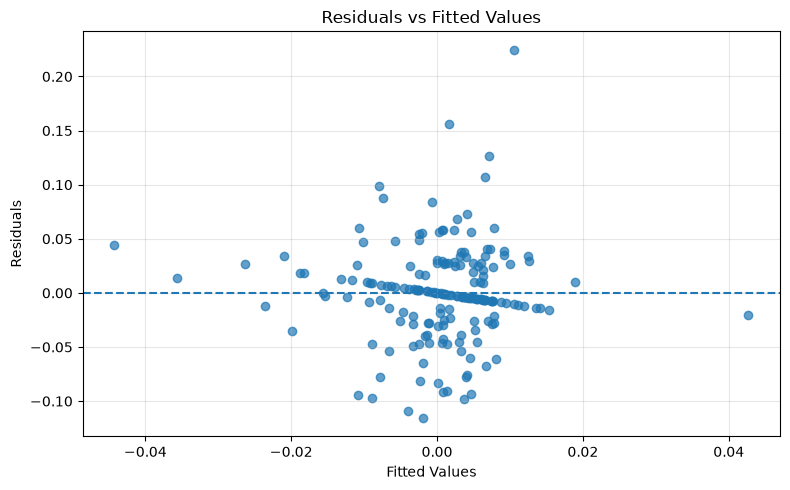

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    model_combined.fittedvalues,
    model_combined.resid,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Residuals scatter randomly around zero with no obvious nonlinear pattern, which supports using a linear model here.

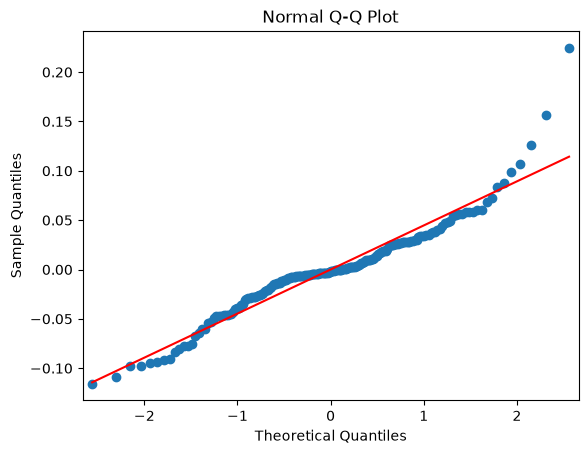

In [14]:
sm.qqplot(
    model_combined.resid,
    line="s"
)

plt.title("Normal Q-Q Plot")

plt.show()

Residuals deviate slightly from normality — not unusual for financial return data, which tends to have heavier tails than a normal distribution would suggest.

In [15]:
bp = het_breuschpagan(
    model_combined.resid,
    model_combined.model.exog
)

bp_result = pd.DataFrame({

    "Statistic":[
        bp[0],
        bp[2]
    ],

    "P-value":[
        bp[1],
        bp[3]
    ]

},
index=[
    "LM Test",
    "F Test"
])

bp_result.round(3)

,Statistic,P-value
LM Test,0.809,0.667
F Test,0.400,0.671


No sign of heteroskedasticity, so the constant-variance assumption behind OLS holds up fine here.

In [16]:
X = regression[
    [
        "wti_return_lag3",
        "vix_level_lag2"
    ]
]

X = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [

    variance_inflation_factor(
        X.values,
        i
    )

    for i in range(X.shape[1])

]

vif.round(3)

,Variable,VIF
0,const,9.007
1,wti_return_lag3,1.006
2,vix_level_lag2,1.006


Both predictors have VIF values close to one, so multicollinearity isn't a concern — each variable is contributing distinct information.

In [17]:
dw = durbin_watson(
    model_combined.resid
)

print(
    f"Durbin-Watson Statistic: {dw:.3f}"
)

Durbin-Watson Statistic: 1.396


The Durbin-Watson statistic comes out around 1.40, pointing to mild positive autocorrelation in the residuals. Worth keeping in mind — a time-series model might handle this better than plain OLS.

# Key Findings

WTI monthly returns lagged three months stay significant even after controlling for VIX level (β = 0.059, p = 0.042). VIX level at a two-month lag doesn't hold up in the combined model (β = -0.0008, p = 0.108).

The model overall is statistically significant (F-test p = 0.027), though explanatory power is modest — R² of 3.8%, adjusted R² of 2.7%. Diagnostics look clean on heteroskedasticity and multicollinearity, but residuals aren't quite normal and the Durbin-Watson statistic (~1.40) suggests mild positive autocorrelation.

## Business Conclusion

WTI returns look like a modest but genuine early-warning signal for vessel-value moves about three months out. Given the low explanatory power and the autocorrelation in the residuals, it's best used as a supplementary monitoring input rather than something to forecast off of on its own.